# DPRACO Demo: Adult + Demographic Parit

This notebook demonstrates a DPRACO run on the Adult dataset with the Demographic Parity constraint.

In [5]:
import os
from pathlib import Path

# Set this before importing jax.
JAX_CPU_ONLY = True
if JAX_CPU_ONLY:
    os.environ["JAX_PLATFORMS"] = "cpu"
    os.environ["CUDA_VISIBLE_DEVICES"] = ""

import matplotlib.pyplot as plt
from jax import random
from omegaconf import OmegaConf

from dpraco.data import get_data_stream
from dpraco.models import get_model
from dpraco.training.training_routine import train_and_evaluate


def resolve_repo_root() -> Path:
    return Path.cwd().resolve()


def compute_mean_gap(metric1, metric2):
    return abs(sum(metric1) - sum(metric2)) / len(metric1)


EXP_FOLDER = resolve_repo_root()
CONF = EXP_FOLDER / "conf"
DATA_ROOT = EXP_FOLDER.parent / "data"


def load_cfg(dataset_file, algorithm_file, data_subdir, demo_file):
    base_cfg = OmegaConf.load(CONF / "dpraco.yaml")
    dataset_cfg = OmegaConf.load(CONF / "dataset" / dataset_file)
    dataset_cfg.data_path = DATA_ROOT / data_subdir
    algorithm_cfg = OmegaConf.load(CONF / "algorithm" / algorithm_file)
    model_cfg = OmegaConf.load(CONF / "model" / "logistic_regression.yaml")
    demo_cfg = OmegaConf.load(CONF / "demo" / demo_file)

    return OmegaConf.merge(
        base_cfg,
        OmegaConf.create(
            {"dataset": dataset_cfg, "algorithm": algorithm_cfg, "model": model_cfg}
        ),
        demo_cfg,
    )


def run_experiment(cfg):
    key = random.PRNGKey(cfg.training_params.seed)
    data_key, model_key, training_key = random.split(key, num=3)

    train_stream, val_data, test_data = get_data_stream(
        cfg, data_key, seed=cfg.training_params.seed
    )
    state = get_model(cfg, model_key)
    metrics_df = train_and_evaluate(
        cfg=cfg,
        state=state,
        train_stream=train_stream,
        rng=training_key,
        test_data=test_data,
        val_data=val_data,
    )

    train_soft_hard_gap = compute_mean_gap(
        metrics_df["train_soft_constraint"].to_numpy(),
        metrics_df["train_hard_constraint"].to_numpy(),
    )

    for split in ["train", "val", "test"]:
        recall_col = f"{split}_recall"
        fnr_col = f"{split}_fnr"
        if recall_col in metrics_df.columns:
            metrics_df[fnr_col] = 1.0 - metrics_df[recall_col]

    return metrics_df, train_soft_hard_gap


## Prerequisites

- Dependencies are installed in your current Python environment.
- Adult dataset files are present under `data/adult` in this repository.
- You are using a Python kernel from this project environment.

Training can take time depending on hardware.

In [6]:
EPSILON = 1.0
GAMMA = 0.15
SEED = 2189

In [7]:
cfg = load_cfg(
    dataset_file="adult.yaml",
    algorithm_file="dpraco_demographic_parity.yaml",
    data_subdir="adult",
    demo_file="adult_demographic_parity_demo.yaml",
)

cfg.training_params.target_epsilon = EPSILON
cfg.algorithm.gamma = GAMMA
cfg.training_params.seed = SEED

{
    "dataset": cfg.dataset.name,
    "algorithm": cfg.algorithm.name,
    "model": cfg.model.name,
    "epsilon": cfg.training_params.target_epsilon,
    "gamma": cfg.algorithm.gamma,
    "seed": cfg.training_params.seed,
    "number_of_steps": cfg.training_params.number_of_steps,
}

{'dataset': 'adult',
 'algorithm': 'dpraco',
 'model': 'logistic_regression',
 'epsilon': 1.0,
 'gamma': 0.15,
 'seed': 2189,
 'number_of_steps': 1000}

In [8]:
metrics_df, train_soft_hard_gap = run_experiment(cfg)
len(metrics_df), train_soft_hard_gap

(41, Array(0.00599331, dtype=float32))

In [9]:
if "metrics_df" not in globals():
    raise RuntimeError("`metrics_df` not found. Run the training cell above first.")

display_cols = [
    "step",
    "train_accuracy",
    "test_accuracy",
    "train_hard_constraint",
    "test_hard_constraint",
    "train_soft_constraint",
    "test_soft_constraint",
]

existing_cols = [c for c in display_cols if c in metrics_df.columns]
metrics_df[existing_cols].tail(10)

,step,train_accuracy,test_accuracy,train_hard_constraint,test_hard_constraint,train_soft_constraint,test_soft_constraint
31,775,0.840528,0.843379,0.15513653,0.15418154,0.15156879,0.14655101
32,800,0.840680,0.844241,0.15554446,0.15454128,0.15222842,0.14717665
33,825,0.841059,0.844042,0.15253784,0.1510828,0.15000924,0.14494109
34,850,0.841362,0.844374,0.15291816,0.15167964,0.14972061,0.14462349
35,875,0.841690,0.845037,0.15201628,0.15057296,0.14949572,0.14439744
36,900,0.842069,0.845634,0.15275991,0.15164417,0.15066558,0.14557874
37,925,0.842145,0.845236,0.15264672,0.15127254,0.15024155,0.14513338
38,950,0.842170,0.845169,0.15237093,0.15107095,0.15030074,0.14519149
39,975,0.842246,0.845567,0.15243155,0.15244648,0.15092479,0.14577931
40,1000,0.842120,0.845368,0.15223771,0.15184176,0.15113047,0.14597556


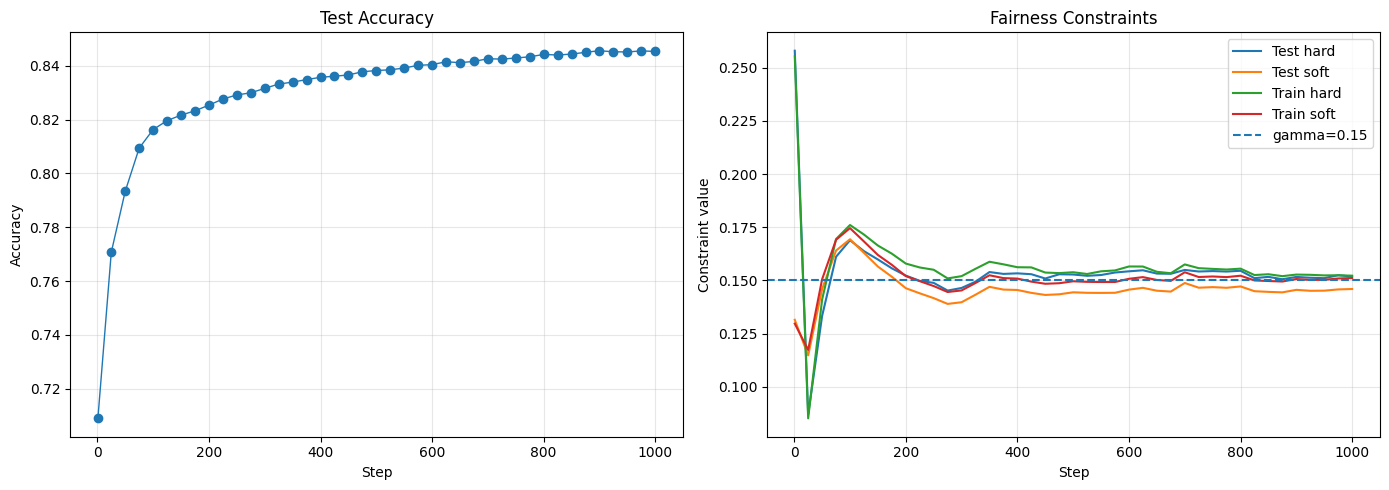

In [10]:
if "metrics_df" not in globals():
    raise RuntimeError("`metrics_df` not found. Run the training cell above first.")

required_cols = [
    "step",
    "test_accuracy",
    "test_hard_constraint",
    "test_soft_constraint",
    "train_hard_constraint",
    "train_soft_constraint",
]

missing = [c for c in required_cols if c not in metrics_df.columns]
if missing:
    raise ValueError(f"Missing expected metric columns: {missing}")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(metrics_df["step"], metrics_df["test_accuracy"], marker="o", linewidth=1)
axes[0].set_title("Test Accuracy")
axes[0].set_xlabel("Step")
axes[0].set_ylabel("Accuracy")
axes[0].grid(True, alpha=0.3)

axes[1].plot(metrics_df["step"], metrics_df["test_hard_constraint"], label="Test hard")
axes[1].plot(metrics_df["step"], metrics_df["test_soft_constraint"], label="Test soft")
axes[1].plot(metrics_df["step"], metrics_df["train_hard_constraint"], label="Train hard")
axes[1].plot(metrics_df["step"], metrics_df["train_soft_constraint"], label="Train soft")
axes[1].axhline(GAMMA, linestyle="--", label=f"gamma={GAMMA}")
axes[1].set_title("Fairness Constraints")
axes[1].set_xlabel("Step")
axes[1].set_ylabel("Constraint value")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()